In [ ]:
# Sales & Business Analytics Platform

## 02 - Sales Performance Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [3]:
df = pd.read_csv(r"C:\Users\USER\Downloads\Data_Analysois_Projects\Sales_Business_analytics\train.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Order Date"] 

0      2017-11-08
1      2017-11-08
2      2017-06-12
3      2016-10-11
4      2016-10-11
          ...    
9795   2017-05-21
9796   2016-01-12
9797   2016-01-12
9798   2016-01-12
9799   2016-01-12
Name: Order Date, Length: 9800, dtype: datetime64[ns]

In [7]:
## 1. Overall Business KPIs

total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

average_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", average_order_value)

Total Sales: 2261536.7827
Total Orders: 4922
Total Customers: 793
Average Order Value: 459.4751691791954


In [ ]:
## 2. Sales by Category

In [8]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

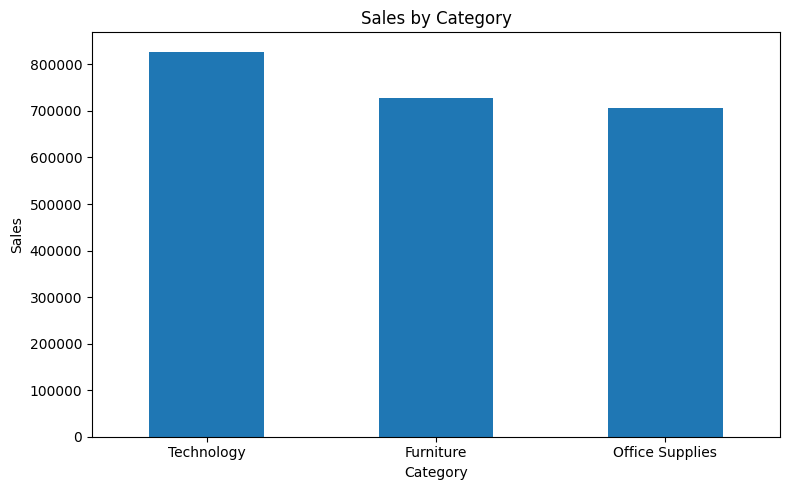

In [9]:
category_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
## 3. Regional Sales Performance

In [10]:
region_analysis = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Orders=("Order ID", "nunique")
)

region_analysis

,Sales,Orders
Region,,
Central,492646.9132,1156
East,669518.7260,1369
South,389151.4590,810
West,710219.6845,1587


In [ ]:
## 4. Customer Segment Analysis

In [12]:
segment_analysis = df.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Orders=("Order ID", "nunique"),
    Customers=("Customer ID", "nunique")
)

segment_analysis

,Sales,Orders,Customers
Segment,,,
Consumer,1.148061e+06,2537,409
Corporate,6.884941e+05,1491,236
Home Office,4.249822e+05,894,148


In [ ]:
## 5. Yearly Sales Performance

In [13]:
yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)

yearly_sales

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

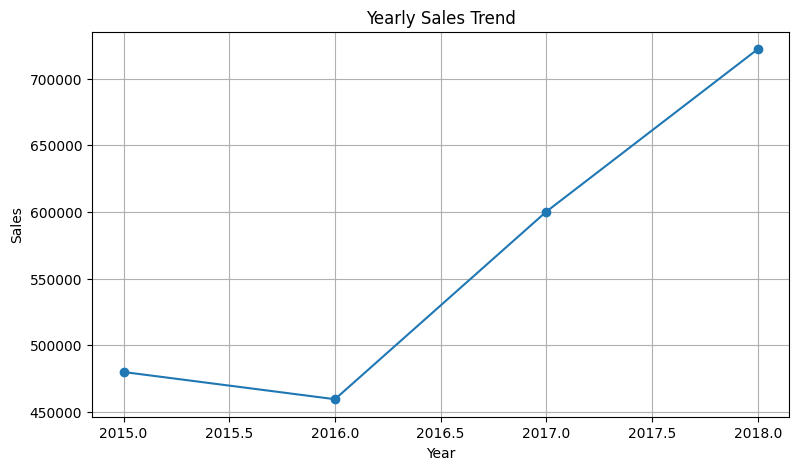

In [14]:
yearly_sales.plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [15]:
## 6. Monthly Sales Trend

monthly_sales = (
    df.groupby("Year_Month")["Sales"]
    .sum()
)

monthly_sales

Year_Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040


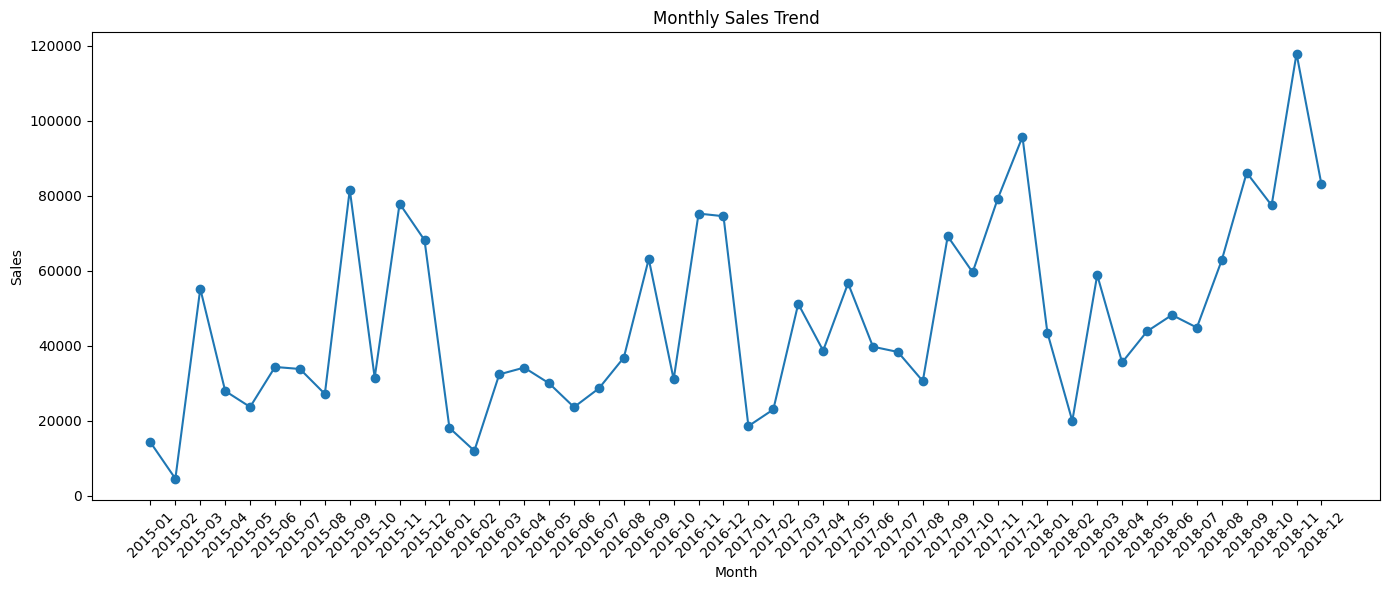

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
## 7. Top Performing States

state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

state_sales.head(10)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

In [18]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

In [ ]:
# 8. Business Questions

### Questions

## 1. Which category generates the highest sales?
## 2. Which category generates the highest profit?
## 3. Which region generates the most revenue?
## 4. Which customer segment performs best?
## 5. Which state has the highest sales?
## 6. How do sales change over time?
## 7. Which sub-categories contribute the most sales?

In [ ]:
# 9. Key Findings

The findings discovered during the analysis.

- The highest-performing category was Technology.
- The highest-performing region was West.
- Sales showed Rising trend over time.
- The most valuable customer segment was Phones.